<a href="https://colab.research.google.com/github/asad-iqbal78/ai-internship/blob/main/week_2_badminton_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os
print(os.listdir())

['.config', 'sample_data']


In [2]:
import zipfile
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
  zip_ref.extractall("badminton_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os
print(os.listdir("badminton_data"))

['bwf-ss-gamedata-2015-2017-new.csv']


In [5]:
import pandas as pd
file_path = "badminton_data/bwf-ss-gamedata-2015-2017-new.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 11872
Columns: 6


In [8]:
df.head()

,Year,Tournament,Round,Match,Type,Scores
0,2015,All England Open,1,japan-indonesia,XD,0-0;0-0;1-0;2-0;2-1;3-1;4-1;5-1;6-1;7-1;7-2;8-...
1,2015,All England Open,1,japan-indonesia,XD,0-0;0-0;0-1;1-1;1-2;2-2;3-2;3-3;4-3;4-4;4-5;4-...
2,2015,All England Open,1,germany-indonesia,WD,0-0;0-0;0-1;0-2;0-3;0-4;0-5;1-5;2-5;3-5;3-6;3-...
3,2015,All England Open,1,germany-indonesia,WD,0-0;0-0;1-0;2-0;2-1;2-2;3-2;3-3;4-3;4-4;5-4;5-...
4,2015,All England Open,1,china-england,MD,0-0;0-0;0-1;0-2;1-2;1-3;2-3;3-3;4-3;4-4;5-4;6-...


In [7]:
df.columns

Index(['Year', 'Tournament', 'Round', 'Match', 'Type', 'Scores'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11872 entries, 0 to 11871
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        11872 non-null  int64 
 1   Tournament  11872 non-null  object
 2   Round       11872 non-null  object
 3   Match       11872 non-null  object
 4   Type        11872 non-null  object
 5   Scores      11872 non-null  object
dtypes: int64(1), object(5)
memory usage: 556.6+ KB


In [11]:
df.isnull().sum()

,0
Year,0
Tournament,0
Round,0
Match,0
Type,0
Scores,0


In [12]:
df.head(10)

,Year,Tournament,Round,Match,Type,Scores
0,2015,All England Open,1,japan-indonesia,XD,0-0;0-0;1-0;2-0;2-1;3-1;4-1;5-1;6-1;7-1;7-2;8-...
1,2015,All England Open,1,japan-indonesia,XD,0-0;0-0;0-1;1-1;1-2;2-2;3-2;3-3;4-3;4-4;4-5;4-...
2,2015,All England Open,1,germany-indonesia,WD,0-0;0-0;0-1;0-2;0-3;0-4;0-5;1-5;2-5;3-5;3-6;3-...
3,2015,All England Open,1,germany-indonesia,WD,0-0;0-0;1-0;2-0;2-1;2-2;3-2;3-3;4-3;4-4;5-4;5-...
4,2015,All England Open,1,china-england,MD,0-0;0-0;0-1;0-2;1-2;1-3;2-3;3-3;4-3;4-4;5-4;6-...
5,2015,All England Open,1,china-england,MD,0-0;0-0;0-1;1-1;1-2;2-2;3-2;3-3;4-3;5-3;6-3;6-...
6,2015,All England Open,1,china-korea,WD,0-0;0-0;1-0;2-0;2-1;3-1;3-2;4-2;4-3;5-3;6-3;7-...
7,2015,All England Open,1,china-korea,WD,0-0;0-0;0-1;0-2;0-3;1-3;1-4;2-4;2-5;2-6;2-7;3-...
8,2015,All England Open,1,china-korea,WD,0-0;0-0;1-0;1-1;2-1;3-1;4-1;5-1;5-2;6-2;7-2;8-...
9,2015,All England Open,1,chinesetaipei-thailand,MS,0-0;0-0;1-0;1-1;1-2;2-2;3-2;3-3;3-4;4-4;4-5;5-...


In [14]:
df["Type"].value_counts()

,count
Type,
MS,2609
MD,2540
WS,2442
WD,2312
XD,1969


In [16]:
df["Round"].value_counts()

,count
Round,
1,5619
2,3287
Q,1695
S,846
F,425


In [17]:
df["Year"].value_counts().sort_index()

,count
Year,
2015,4063
2016,3812
2017,3997


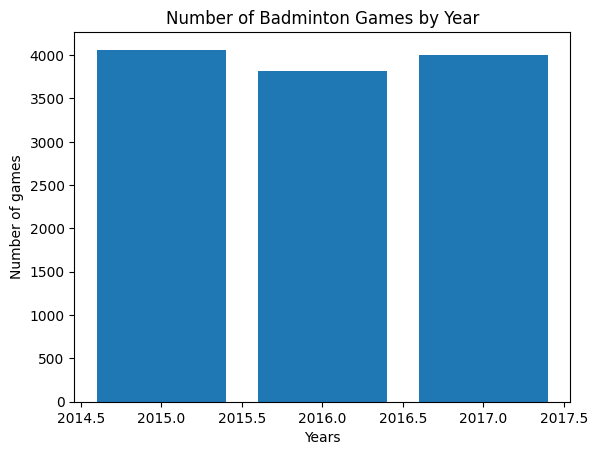

In [19]:
import matplotlib.pyplot as plt
years_counts = df["Year"].value_counts().sort_index()

plt.bar(years_counts.index, years_counts.values)

plt.xlabel("Years")
plt.ylabel("Number of games")
plt.title("Number of Badminton Games by Year")

plt.show()

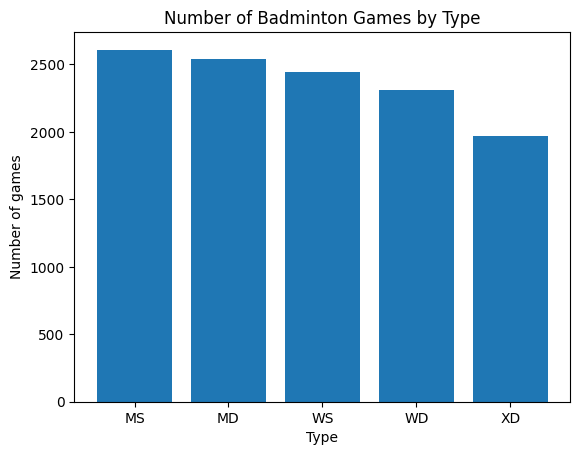

In [20]:
type_counts = df["Type"].value_counts()
plt.bar(type_counts.index, type_counts.values)

plt.xlabel("Type")
plt.ylabel("Number of games")
plt.title("Number of Badminton Games by Type")

plt.show()

In [22]:
year_type = pd.crosstab(df["Year"], df["Type"])

year_type

Type,MD,MS,WD,WS,XD
Year,,,,,
2015,837,876,800,846,704
2016,836,860,707,788,621
2017,867,873,805,808,644


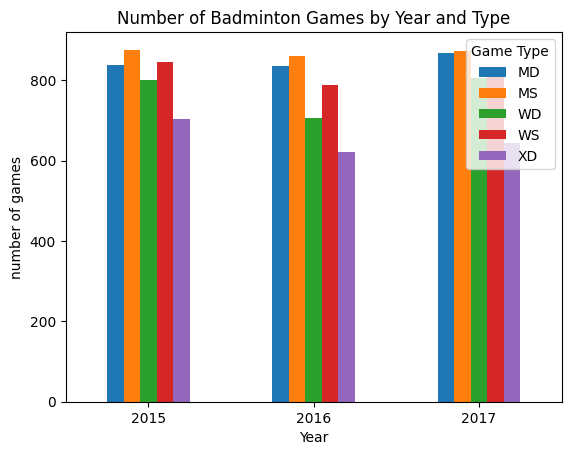

In [23]:
year_type.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("number of games")
plt.title("Number of Badminton Games by Year and Type")

plt.xticks(rotation=0)
plt.legend(title="Game Type")

plt.show()